# Microscope Design Curves

This notebook assembles the complete set of **design curves** (lens focal lengths and drive currents) for a model TEM column, covering three operating modes:

| Mode | Control variable | Source |
|------|-----------------|--------|
| **A — Condenser spot size** | Spot index (1–8) | Solved here (CL1, CL3) |
| **B — IL magnification** | System magnification (30k–600k×) | Loaded from `microscope.toml` |
| **C — Diffraction camera length** | Camera length | Loaded from `microscope.toml` |

### Data flow

- Column geometry (z-positions, turns, Gc) is read from `microscope.toml`.
- IL imaging and diffraction mode curves are read from `microscope.toml` mode tables.
- This notebook recomputes condenser curves and can write updated mode tables back to `microscope.toml`.
- Obj_post and PL1 currents are fixed by the objective and projector focal lengths.

### Output

The notebook updates mode-table design curves directly in `microscope.toml`.

## 1 — Imports and Microscope Configuration

All physical dimensions and lens parameters are loaded from `microscope.toml`. Solver targets are defined inline below. Distances are in **metres**, voltages in **volts**.

In [128]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.01"

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import brentq, least_squares

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix
from temgym_core.constants import compute_Rc_from_voltage
from temgym_core.microscope_model import MicroscopeModel, OperatingMode, LensConfig

try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib  # type: ignore[no-redef]

%matplotlib widget

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# ══════════════════════════════════════════════════════════════
# Load column geometry from microscope.toml
# ══════════════════════════════════════════════════════════════

toml_path = Path("microscope.toml")
with open(toml_path, "rb") as f:
    toml_cfg = tomllib.load(f)

# ── Beam ──
beam_cfg = toml_cfg['beam']

# ── Lens z-positions, turns, Gc ──
lens_table = toml_cfg['lenses']
z = {name: float(spec['z_m']) for name, spec in lens_table.items()}
turns_all = {name: float(spec['turns']) for name, spec in lens_table.items()}
Gc_all = {name: float(spec['Gc']) for name, spec in lens_table.items() if 'Gc' in spec}

# ── Aperture ──
z_aperture = float(toml_cfg['apertures']['C_aperture']['z_m'])

# ── Distances derived from toml z-positions ──
geometry = {
    'd_Source_to_CL1':          z['CL1'],
    'd_CL1_to_CL3':            z['CL3'] - z['CL1'],
    'd_CL3_to_Aperture':       z_aperture - z['CL3'],
    'd_Aperture_to_Cmini':     z['C_mini'] - z_aperture,
    'd_Cmini_to_ObjPrefield':  z['Obj_prefield'] - z['C_mini'],
    'd_ObjPrefield_to_Sample':  5.0e-3,
    'd_Sample_to_ObjPost':      2.3e-3,
    'd_ObjPost_to_IL1':         z['IL1'] - z['Obj_post'],
    'd_IL1_to_IL2':             z['IL2'] - z['IL1'],
    'd_IL2_to_IL3':             z['IL3'] - z['IL2'],
    'd_IL3_to_PL1':             z['PL1'] - z['IL3'],
    'd_PL1_to_detector':        0.325,
}

# Sanity: Obj_prefield + 5 mm + 2.3 mm should equal Obj_post z
_z_obj_post_check = z['Obj_prefield'] + geometry['d_ObjPrefield_to_Sample'] + geometry['d_Sample_to_ObjPost']
assert abs(_z_obj_post_check - z['Obj_post']) < 1e-6, (
    f"Obj_post z mismatch: derived {_z_obj_post_check:.6f} vs toml {z['Obj_post']:.6f}"
)

# ── Fixed focal lengths (not parameterised by Gc in the solver) ──
optics = {
    'f_Cmini_m':       5.0e-3,
    'f_ObjPrefield_m': 5.0e-3,
}

# ── Condenser solver targets ──
solver_targets = {
    'condenser_spots': {
        'N_spots': 8,
        'target_sample_min_nm': 500.0,
        'target_sample_max_nm': 5000.0,
        'I_A_bounds':      {'CL1': (0.4, 1.9), 'CL3': (0.4, 1.9)},
        'f_solver_bounds':  {'CL1': (0.8e-3, 120.0e-3), 'CL3': (0.8e-3, 900.0e-3)},
        'f_tens_bounds':    {'CL1': (5.0e-3, 30.0e-3), 'CL3': (5.0e-3, 30.0e-3)},
        'scan_points': 2500,
    },
}

# ══════════════════════════════════════════════════════════════
# Derived quantities
# ══════════════════════════════════════════════════════════════

U_accel_V = beam_cfg['voltage_kV'] * 1000.0
Rc_phys = float(compute_Rc_from_voltage(U_accel_V))

# --- Condenser geometry ---
geometry_cond = {
    'd_S_C1':      geometry['d_Source_to_CL1'],
    'd_C1_C3':     geometry['d_CL1_to_CL3'],
    'd_C3_A':      geometry['d_CL3_to_Aperture'],
    'd_A_Cmini':   geometry['d_Aperture_to_Cmini'],
    'd_Cmini_OPL': geometry['d_Cmini_to_ObjPrefield'],
    'f_Cmini':     optics['f_Cmini_m'],
    'f_OPL':       optics['f_ObjPrefield_m'],
}

turns_cond    = {k: turns_all[k] for k in ['CL1', 'CL3']}
Gc_phys_cond  = {k: Gc_all[k]   for k in ['CL1', 'CL3']}
I_A_bounds_cond = solver_targets['condenser_spots']['I_A_bounds']
AT_bounds_cond  = {k: (turns_cond[k] * lo, turns_cond[k] * hi) for k, (lo, hi) in I_A_bounds_cond.items()}

N_spots                      = solver_targets['condenser_spots']['N_spots']
f3_scan_points               = solver_targets['condenser_spots']['scan_points']
sample_rel_tolerance         = 2e-2
conjugate_eps                = 1e-6
requested_sample_target_min_nm = solver_targets['condenser_spots']['target_sample_min_nm']
requested_sample_target_max_nm = solver_targets['condenser_spots']['target_sample_max_nm']
f_solver_bounds_cond         = solver_targets['condenser_spots']['f_solver_bounds']
enforce_tens_mm_cond         = True
f_tens_bounds_cond           = solver_targets['condenser_spots']['f_tens_bounds']

virtual_source_diameter_nm   = beam_cfg['virtual_source_diameter_nm']
source_half_angle_mrad       = beam_cfg['source_half_angle_mrad']
sample_distance_from_opl_m   = geometry_cond['f_OPL']
source_sigma_x_m             = 0.5 * virtual_source_diameter_nm * 1e-9
source_sigma_theta_rad       = source_half_angle_mrad * 1e-3

# --- Objective and projector parameters ---
M_obj  = -30.0
M_proj = -100.0

# --- Objective imaging ---
u_obj_m            = geometry['d_Sample_to_ObjPost']
v_obj_m            = abs(M_obj) * u_obj_m
f_obj_required_m   = u_obj_m * v_obj_m / (u_obj_m + v_obj_m)
d_ObjPost_to_IL1   = geometry['d_ObjPost_to_IL1']
d_obj_image_to_il1 = d_ObjPost_to_IL1 - v_obj_m

if d_obj_image_to_il1 <= 0:
    raise ValueError(
        f'Objective image at v={v_obj_m*1e3:.1f} mm past Obj_post exceeds '
        f'd_ObjPost_to_IL1={d_ObjPost_to_IL1*1e3:.1f} mm.'
    )

# --- Projector geometry ---
d_pre_PL1_image_to_PL1 = geometry['d_PL1_to_detector'] / abs(M_proj)

geometry_proj = {
    'd_il3_to_pl1':            geometry['d_IL3_to_PL1'],
    'd_pre_pl1_image_to_pl1':  d_pre_PL1_image_to_PL1,
    'd_pl1_to_detector':       geometry['d_PL1_to_detector'],
}

# --- IL geometry ---
geometry_mag = {
    'd_obj_image_to_il1': d_obj_image_to_il1,
    'd_il1_to_il2':       geometry['d_IL1_to_IL2'],
    'd_il2_to_il3':       geometry['d_IL2_to_IL3'],
    'd_il3_to_image':     geometry_proj['d_il3_to_pl1'] - geometry_proj['d_pre_pl1_image_to_pl1'],
}

# --- Diffraction geometry (BFP relay, metadata only) ---
d_bfp_to_il1 = float(d_ObjPost_to_IL1 - f_obj_required_m)
if d_bfp_to_il1 <= 0:
    raise ValueError('Invalid diffraction geometry: BFP must be upstream of IL1.')

geometry_diff = {
    'd_bfp_to_il1':   d_bfp_to_il1,
    'd_il1_to_il2':   geometry['d_IL1_to_IL2'],
    'd_il2_to_il3':   geometry['d_IL2_to_IL3'],
    'd_il3_to_image': geometry_mag['d_il3_to_image'],
}

f_pl1_target_m = 1.0 / (1.0 / geometry_proj['d_pre_pl1_image_to_pl1'] + 1.0 / geometry_proj['d_pl1_to_detector'])

# --- Rotation cancellation target (Obj_post + PL1 fixed currents) ---
Gc_objpost_cfg = Gc_all['Obj_post']
Gc_pl1_cfg     = Gc_all['PL1']
ni_objpost_mag = float(np.sqrt(1.0 / (Gc_objpost_cfg * f_obj_required_m)))
ni_pl1_mag     = float(np.sqrt(1.0 / (Gc_pl1_cfg * f_pl1_target_m)))
theta_target   = float(Rc_phys * (ni_objpost_mag + ni_pl1_mag))

# --- Summary ---
print(f'Column geometry loaded from {toml_path}')
print(f'Rc = {Rc_phys:.4e} rad/AT')
print(f'Objective: M_obj = {M_obj},  u = {u_obj_m*1e3:.3f} mm,  v = {v_obj_m*1e3:.3f} mm,  '
      f'f = {f_obj_required_m*1e3:.4f} mm,  NI = {ni_objpost_mag:.1f} AT')
print(f'd_obj_image → IL1 = {d_obj_image_to_il1*1e3:.3f} mm  '
      f'(d_ObjPost → IL1 = {d_ObjPost_to_IL1*1e3:.3f} mm)')
print(f'BFP → IL1: {d_bfp_to_il1*1e3:.3f} mm')
print(f'IL gaps [mm]:  IL1↔IL2 = {geometry_mag["d_il1_to_il2"]*1e3:.3f},  '
      f'IL2↔IL3 = {geometry_mag["d_il2_to_il3"]*1e3:.3f},  '
      f'IL3↔image = {geometry_mag["d_il3_to_image"]*1e3:.3f}')
print(f'PL1: f = {f_pl1_target_m*1e3:.4f} mm,  d_IL3↔PL1 = {geometry_proj["d_il3_to_pl1"]*1e3:.3f} mm')
print(f'Rotation target (Obj_post + PL1): theta = {np.rad2deg(theta_target):.2f}°')

Column geometry loaded from microscope.toml
Rc = 5.3015e-04 rad/AT
Objective: M_obj = -30.0,  u = 2.300 mm,  v = 69.000 mm,  f = 2.2258 mm,  NI = 7494.0 AT
d_obj_image → IL1 = 133.442 mm  (d_ObjPost → IL1 = 202.442 mm)
BFP → IL1: 200.216 mm
IL gaps [mm]:  IL1↔IL2 = 77.105,  IL2↔IL3 = 62.500,  IL3↔image = 48.833
PL1: f = 3.2178 mm,  d_IL3↔PL1 = 52.083 mm
Rotation target (Obj_post + PL1): theta = 416.95°


In [129]:
# Load fitted IL manifold from intermediate_lens constraint study.
# Option 1: use fitted manifold directly for design-curve mode tables.
il_npz_path = Path("data/il_constraint_study.npz")
use_fitted_gc = False
use_fitted_mode_tables = False


def _solve_m_obj_from_delta(delta_m, u_m):
    """Infer |M_obj| from delta = d1_cam - d1_img = v - f, with v=|M|u."""
    if delta_m <= 0.0 or u_m <= 0.0:
        return None
    r = delta_m / u_m
    disc = r * r + 4.0 * r
    if disc <= 0.0:
        return None
    return 0.5 * (r + np.sqrt(disc))


if il_npz_path.exists():
    print(f"\n{'='*60}")
    print(f"Loading IL fit export from: {il_npz_path}")
    print(f"{'='*60}")

    with np.load(il_npz_path) as npz:
        alpha_f = np.array(npz['alpha_f'], dtype=float)
        d1i_f = float(npz['d1i_f'])
        d1c_f = float(npz['d1c_f'])
        d2_f = float(npz['d2_f'])
        d4_f = float(npz['d4_f'])
        D3_MM_fit = float(npz['D3_MM'])
        si_best = int(npz['si_best'])
        sc_best = int(npz['sc_best'])
        s_img_f = float(npz['s_img_f'])
        s_cam_f = float(npz['s_cam_f'])
        x_img_data = np.array(npz['x_img'], dtype=float)
        x_cam_data = np.array(npz['x_cam'], dtype=float)
        mags_ref_fit = np.array(npz['mags_ref'], dtype=float)
        cl_ref_m_fit = np.array(npz['cl_ref_m'], dtype=float)

    D3_fit_m = D3_MM_fit * 1e-3

    # Use fitted IL constants for current->focal conversion.
    Gc_fit = {
        'IL1': alpha_f[0] / (turns_all['IL1'] ** 2),
        'IL2': alpha_f[1] / (turns_all['IL2'] ** 2),
        'IL3': alpha_f[2] / (turns_all['IL3'] ** 2),
    }
    Gc_all.update(Gc_fit)
    use_fitted_gc = True

    print("\nFitted IL lens constants (from measured DAC curves):")
    print("         Fitted [1/f·m]  Original [1/f·m]  Ratio (fit/orig)")
    Gc_orig = 8.0e-6
    for name in ['IL1', 'IL2', 'IL3']:
        print(f"  {name}:  {Gc_fit[name]:.4e}      {Gc_orig:.4e}          {Gc_fit[name]/Gc_orig:.3f}x")

    # Reconstruct the fitted manifold exactly as in intermediate_lens_system.
    def _phi2_exact(phi3, m, d):
        d1, d2, d3, d4 = d
        num = d1 * m + (d2 + d3 + d4) - (d2 + d3) * d4 * phi3
        den = d2 * ((d3 + d4) - d3 * d4 * phi3)
        return num / den if abs(den) > 1e-30 else np.nan

    def _phi1_exact(phi2, phi3, m, d):
        d1, d2, d3, d4 = d
        A0 = 1.0 - (d3 + d4) * phi2 - d4 * phi3 + d3 * d4 * phi2 * phi3
        A1 = -(d2 + d3 + d4) + d2 * (d3 + d4) * phi2 + (d2 + d3) * d4 * phi3 - d2 * d3 * d4 * phi2 * phi3
        return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan

    def _model_at_data(m_arr, x3_data, d, alpha):
        out = np.full((3, len(m_arr)), np.nan)
        for j, m in enumerate(m_arr):
            p3 = alpha[2] * x3_data[j]**2
            p2 = _phi2_exact(p3, m, d)
            if (not np.isfinite(p2)) or p2 <= 0:
                continue
            p1 = _phi1_exact(p2, p3, m, d)
            if (not np.isfinite(p1)) or p1 <= 0:
                continue
            out[0, j] = np.sqrt(p1 / alpha[0])
            out[1, j] = np.sqrt(p2 / alpha[1])
            out[2, j] = x3_data[j]
        return out

    d_img_fit = np.array([d1i_f, d2_f, 1.0, d4_f], dtype=float)
    d_cam_fit = np.array([d1c_f, d2_f, 1.0, d4_f], dtype=float)

    m_img_fit = si_best * s_img_f * mags_ref_fit
    # s_cam_f was fitted against camera length in mm in intermediate_lens_system.
    m_cam_fit = sc_best * s_cam_f * (cl_ref_m_fit * 1e3)

    x_img_fit = _model_at_data(m_img_fit, x_img_data[2], d_img_fit, alpha_f)
    x_cam_fit = _model_at_data(m_cam_fit, x_cam_data[2], d_cam_fit, alpha_f)

    valid_img = int(np.sum(np.isfinite(x_img_fit[0])))
    valid_cam = int(np.sum(np.isfinite(x_cam_fit[0])))
    use_fitted_mode_tables = (valid_img == x_img_fit.shape[1]) and (valid_cam == x_cam_fit.shape[1])

    print("\nFitted manifold reconstruction:")
    print(f"  imaging valid points:     {valid_img}/{x_img_fit.shape[1]}")
    print(f"  diffraction valid points: {valid_cam}/{x_cam_fit.shape[1]}")
    print(f"  fitted d (norm): d1i={d1i_f:.4f}, d1c={d1c_f:.4f}, d2={d2_f:.4f}, d3=1.0000, d4={d4_f:.4f}")

    if use_fitted_mode_tables:
        print("Using fitted IL manifold for mode tables (option 1).")

        # Keep design notebook geometry self-consistent with fitted manifold export.
        d1i_m = d1i_f * D3_fit_m
        d1c_m = d1c_f * D3_fit_m
        d2_m = d2_f * D3_fit_m
        d4_m = d4_f * D3_fit_m

        m_obj_abs = _solve_m_obj_from_delta(d1c_m - d1i_m, u_obj_m)
        if m_obj_abs is None:
            print("WARNING: could not infer objective magnification from fitted d1 values; keeping existing objective geometry.")
        else:
            M_obj = -float(m_obj_abs)
            v_obj_m = float(m_obj_abs * u_obj_m)
            f_obj_required_m = float((u_obj_m * v_obj_m) / (u_obj_m + v_obj_m))

            d_obj_image_to_il1 = float(d1i_m)
            d_bfp_to_il1 = float(d1c_m)
            d_ObjPost_to_IL1 = float(v_obj_m + d_obj_image_to_il1)

            geometry['d_ObjPost_to_IL1'] = d_ObjPost_to_IL1
            geometry['d_IL1_to_IL2'] = float(d2_m)
            geometry['d_IL2_to_IL3'] = float(D3_fit_m)

            geometry_mag['d_obj_image_to_il1'] = d_obj_image_to_il1
            geometry_mag['d_il1_to_il2'] = float(d2_m)
            geometry_mag['d_il2_to_il3'] = float(D3_fit_m)
            geometry_mag['d_il3_to_image'] = float(d4_m)

            geometry_diff['d_bfp_to_il1'] = d_bfp_to_il1
            geometry_diff['d_il1_to_il2'] = float(d2_m)
            geometry_diff['d_il2_to_il3'] = float(D3_fit_m)
            geometry_diff['d_il3_to_image'] = float(d4_m)

            geometry_proj['d_il3_to_pl1'] = float(d4_m + geometry_proj['d_pre_pl1_image_to_pl1'])

            ni_objpost_mag = float(np.sqrt(1.0 / (Gc_objpost_cfg * f_obj_required_m)))
            theta_target = float(Rc_phys * (ni_objpost_mag + ni_pl1_mag))

            print("\nOverriding objective + IL geometry from fitted manifold:")
            print(f"  M_obj (inferred):      {M_obj:+.6f}")
            print(f"  u_obj [mm]:            {u_obj_m*1e3:.3f}")
            print(f"  v_obj [mm]:            {v_obj_m*1e3:.3f}")
            print(f"  f_obj [mm]:            {f_obj_required_m*1e3:.6f}")
            print(f"  d_obj_image->IL1 [mm]: {d_obj_image_to_il1*1e3:.6f}")
            print(f"  d_bfp->IL1 [mm]:       {d_bfp_to_il1*1e3:.6f}")
            print(f"  d_il1->il2 [mm]:       {geometry_mag['d_il1_to_il2']*1e3:.6f}")
            print(f"  d_il2->il3 [mm]:       {geometry_mag['d_il2_to_il3']*1e3:.6f}")
            print(f"  d_il3->image [mm]:     {geometry_mag['d_il3_to_image']*1e3:.6f}")
    else:
        print("WARNING: fitted manifold has invalid points; falling back to TOML mode tables.")

else:
    print(f"\nWARNING: {il_npz_path} not found.")
    print("Continuing with TOML IL constants and TOML mode tables.")
    print("To use fitted manifold, run intermediate_lens_system.ipynb export cell.")


Loading IL fit export from: data/il_constraint_study.npz

Fitted IL lens constants (from measured DAC curves):
         Fitted [1/f·m]  Original [1/f·m]  Ratio (fit/orig)
  IL1:  1.2462e-06      8.0000e-06          0.156x
  IL2:  4.2935e-06      8.0000e-06          0.537x
  IL3:  1.6645e-06      8.0000e-06          0.208x

Fitted manifold reconstruction:
  imaging valid points:     14/14
  diffraction valid points: 15/15
  fitted d (norm): d1i=0.2648, d1c=3.2027, d2=1.2337, d3=1.0000, d4=0.8333
Using fitted IL manifold for mode tables (option 1).

Overriding objective + IL geometry from fitted manifold:
  M_obj (inferred):      -80.823334
  u_obj [mm]:            2.300
  v_obj [mm]:            185.894
  f_obj [mm]:            2.271891
  d_obj_image->IL1 [mm]: 16.548045
  d_bfp->IL1 [mm]:       200.169823
  d_il1->il2 [mm]:       77.105471
  d_il2->il3 [mm]:       62.500000
  d_il3->image [mm]:     52.082758


## Option 2: Load fitted IL lens constants from intermediate_lens_system

This section loads the fitted Gc coefficients (lens constants derived from actual DAC table fitting) from the intermediate-lens constraint study. We use **only** the lens constants, not the distances, because the two notebooks use different optical conventions. We'll then check whether these measured optics produce B≈0 with our current geometry.


## 2 — Transfer-Matrix Primitives and Shared Helpers

These utility functions are used by both the condenser and IL solvers:
- `build_chain` / `extract_abcd` — compose 3×3 transfer matrices and extract the 2×2 ABCD elements.
- `currents_from_focal_lengths` — convert focal lengths to coil currents via $1/f = G_c \cdot NI^2$.
- `scalar_root_solve` — bracket-and-Brentq root finder for design-curve residuals.
- `focal_bounds_from_current_bounds` — invert current limits into focal-length limits.

In [130]:
# ── Transfer-matrix composition ──

def build_chain(elements, xp=np):
    """Compose a sequence of propagation ('P', d) and lens ('L', f) elements."""
    M = xp.eye(3)
    for kind, value in elements:
        if kind == 'P':
            op = propagation_matrix(value, xp=xp)
        elif kind == 'L':
            op = lens_matrix(value, xp=xp)
        else:
            raise ValueError(f'Unknown element kind: {kind}')
        M = op @ M
    return M


def extract_abcd(M):
    """Extract (A, B, C, D) from a 3×3 transfer matrix."""
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1]


# ── Focal length ↔ current conversion ──

def currents_from_focal_lengths(f_map, gc_phys_map, turns_map):
    """Convert {lens_name: focal_length} to {I_A_name, AT_name} using 1/f = Gc·NI²."""
    out = {}
    for k, f in f_map.items():
        if (not np.isfinite(f)) or (f <= 0.0):
            return None
        at = float(np.sqrt(1.0 / (gc_phys_map[k] * f)))
        out[f'I_A_{k}'] = float(at / turns_map[k])
        out[f'AT_{k}'] = at
    return out


def apply_hard_bounds_and_flag(row, i_a_bounds, at_bounds):
    """Return True if all currents in `row` are within bounds."""
    for k, (lo, hi) in i_a_bounds.items():
        if not (lo <= row[f'I_A_{k}'] <= hi):
            return False
    for k, (lo, hi) in at_bounds.items():
        if not (lo <= row[f'AT_{k}'] <= hi):
            return False
    return True


# ── Root-finding helpers ──

def choose_bracket(f_grid, r_grid, prev_root=None):
    """Find a sign-change bracket in (f_grid, r_grid), preferring one near prev_root."""
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g = f_grid[finite]
    r = r_grid[finite]

    candidates = []
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            candidates.append((float(a), float(a)))
        elif ra * rb < 0.0:
            candidates.append((float(a), float(b)))

    if len(candidates) == 0:
        return None
    if prev_root is None:
        return candidates[0]

    mids = np.array([0.5 * (a + b) for (a, b) in candidates], dtype=float)
    j = int(np.argmin(np.abs(mids - prev_root)))
    return candidates[j]


def scalar_root_solve(residual_fn, f_grid, prev_root=None, maxiter=200):
    """Bracket-and-Brentq root finder.  Falls back to nearest-to-zero if no bracket."""
    r_grid = np.array([residual_fn(float(x)) for x in f_grid], dtype=float)
    bracket = choose_bracket(f_grid, r_grid, prev_root=prev_root)

    converged = False
    if bracket is None:
        finite = np.isfinite(r_grid)
        if not np.any(finite):
            raise RuntimeError('No finite residuals in scalar_root_solve')
        g = f_grid[finite]
        r = r_grid[finite]
        root = float(g[np.argmin(np.abs(r))])
    elif bracket[0] == bracket[1]:
        root = float(bracket[0])
        converged = True
    else:
        root = float(brentq(lambda x: residual_fn(float(x)), bracket[0], bracket[1], maxiter=maxiter))
        converged = True

    return root, converged


Condenser focal bounds [mm]: {'CL1': (5.0, 30.0), 'CL3': (5.34, 30.0)}


## 3 — Mode A: Condenser Drive Curves (from `microscope.toml`)

Condenser spot-size design curves are solved in `condenser_system_design.ipynb` and written to `microscope.toml`.  This cell loads the resulting drive-current table from `[modes.illumination.parallel]`.

In [ ]:
# Load condenser spot-size design curves from microscope.toml.
# To regenerate, run condenser_system_design.ipynb.

cond_table   = toml_cfg['modes']['illumination']['parallel']
cond_headers = list(cond_table['headers'])
cond_values  = np.asarray(cond_table['values'], dtype=float)

results_cond = []
for row in cond_values:
    entry = dict(zip(cond_headers, row.tolist()))
    results_cond.append({
        'spot_index': int(round(entry['spotsize'])),
        'I_A_CL1':   float(entry.get('CL1', 0.0)),
        'I_A_CL3':   float(entry.get('CL3', 0.0)),
    })

print(f'Loaded {len(results_cond)} condenser spots from {toml_path}')
for r in results_cond:
    print(f'  Spot {r["spot_index"]}: CL1 = {r["I_A_CL1"]:.4f} A,  CL3 = {r["I_A_CL3"]:.4f} A')

## 4 — Mode B: Magnification Design Curves (from microscope.toml)

The IL imaging table is read from `[modes.imaging.magnification]` in `microscope.toml`.
For each row, IL currents are converted to focal lengths via:

$$f_k = \frac{1}{G_{c,k}\,(N_k I_k)^2}$$

with $G_{c,k}$ and $N_k$ taken from the lens table in `microscope.toml`.

In [132]:
# ── Load IL imaging mode table (fitted manifold preferred) ────────────

mag_results = []

if use_fitted_mode_tables:
    target_system_mags = np.array(mags_ref_fit, dtype=float)
    for j, control in enumerate(target_system_mags):
        i1 = float(x_img_fit[0, j])
        i2 = float(x_img_fit[1, j])
        i3 = float(x_img_fit[2, j])

        at1 = float(turns_all['IL1'] * i1)
        at2 = float(turns_all['IL2'] * i2)
        at3 = float(turns_all['IL3'] * i3)

        f1 = float(1.0 / (Gc_all['IL1'] * at1**2)) if at1 != 0 else np.inf
        f2 = float(1.0 / (Gc_all['IL2'] * at2**2)) if at2 != 0 else np.inf
        f3 = float(1.0 / (Gc_all['IL3'] * at3**2)) if at3 != 0 else np.inf

        mag_results.append({
            'M_system': float(control),
            'f1_m': f1,
            'f2_m': f2,
            'f3_m': f3,
            'I1_A': i1,
            'I2_A': i2,
            'I3_A': i3,
            'AT1': at1,
            'AT2': at2,
            'AT3': at3,
        })

    print('Loaded imaging mode from fitted IL manifold export.')

else:
    mode_mag = toml_cfg['modes']['imaging']['magnification']
    mag_headers = list(mode_mag['headers'])
    mag_values = list(mode_mag['values'])
    mag_idx = {k: i for i, k in enumerate(mag_headers)}

    required_cols = ['mag', 'IL1', 'IL2', 'IL3']
    missing = [c for c in required_cols if c not in mag_idx]
    if missing:
        raise KeyError(f'microscope.toml [modes.imaging.magnification] missing columns: {missing}')

    target_system_mags = np.array([float(row[mag_idx['mag']]) for row in mag_values], dtype=float)

    for row in mag_values:
        i1 = float(row[mag_idx['IL1']])
        i2 = float(row[mag_idx['IL2']])
        i3 = float(row[mag_idx['IL3']])

        at1 = float(turns_all['IL1'] * i1)
        at2 = float(turns_all['IL2'] * i2)
        at3 = float(turns_all['IL3'] * i3)

        f1 = float(1.0 / (Gc_all['IL1'] * at1**2)) if at1 != 0 else np.inf
        f2 = float(1.0 / (Gc_all['IL2'] * at2**2)) if at2 != 0 else np.inf
        f3 = float(1.0 / (Gc_all['IL3'] * at3**2)) if at3 != 0 else np.inf

        mag_results.append({
            'M_system': float(row[mag_idx['mag']]),
            'f1_m': f1,
            'f2_m': f2,
            'f3_m': f3,
            'I1_A': i1,
            'I2_A': i2,
            'I3_A': i3,
            'AT1': at1,
            'AT2': at2,
            'AT3': at3,
        })

    print('Loaded imaging mode from microscope.toml mode table.')

theta_il_img = Rc_phys * np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in mag_results], dtype=float)

print(f'Imaging points: {len(mag_results)}')
print(f'System magnifications: {target_system_mags.astype(int).tolist()}')
print(f'IL rotation [deg]: min = {np.rad2deg(theta_il_img.min()):.2f},  '
      f'max = {np.rad2deg(theta_il_img.max()):.2f}')
print(f'Rotation target (Obj_post + PL1): {np.rad2deg(theta_target):.2f} deg')

Loaded imaging mode from fitted IL manifold export.
Imaging points: 14
System magnifications: [30000, 40000, 50000, 60000, 80000, 100000, 120000, 150000, 200000, 250000, 300000, 400000, 500000, 600000]
IL rotation [deg]: min = 113.93,  max = 116.47
Rotation target (Obj_post + PL1): 414.63 deg


## 5 — Mode C: Diffraction (Camera-Length) Design Curves (from microscope.toml)

The IL diffraction table is read from `[modes.imaging.diffraction]` in `microscope.toml`.
The same current-to-focal conversion is used:

$$f_k = \frac{1}{G_{c,k}\,(N_k I_k)^2}$$

Camera length values are interpreted as metres unless they look like millimetres (max > 5), in which case they are converted to metres.

In [133]:
# ── Load IL diffraction mode table (fitted manifold preferred) ────────

diff_results = []

if use_fitted_mode_tables:
    target_camera_lengths_m = np.array(cl_ref_m_fit, dtype=float)
    for j, Lc_m in enumerate(target_camera_lengths_m):
        i1 = float(x_cam_fit[0, j])
        i2 = float(x_cam_fit[1, j])
        i3 = float(x_cam_fit[2, j])

        at1 = float(turns_all['IL1'] * i1)
        at2 = float(turns_all['IL2'] * i2)
        at3 = float(turns_all['IL3'] * i3)

        f1 = float(1.0 / (Gc_all['IL1'] * at1**2)) if at1 != 0 else np.inf
        f2 = float(1.0 / (Gc_all['IL2'] * at2**2)) if at2 != 0 else np.inf
        f3 = float(1.0 / (Gc_all['IL3'] * at3**2)) if at3 != 0 else np.inf

        diff_results.append({
            'camera_length_target_m': float(Lc_m),
            'f1_m': f1,
            'f2_m': f2,
            'f3_m': f3,
            'I1_A': i1,
            'I2_A': i2,
            'I3_A': i3,
            'AT1': at1,
            'AT2': at2,
            'AT3': at3,
        })

    print('Loaded diffraction mode from fitted IL manifold export.')

else:
    mode_diff = toml_cfg['modes']['imaging']['diffraction']
    diff_headers = list(mode_diff['headers'])
    diff_values = list(mode_diff['values'])
    diff_idx = {k: i for i, k in enumerate(diff_headers)}

    required_cols = ['camera_length', 'IL1', 'IL2', 'IL3']
    missing = [c for c in required_cols if c not in diff_idx]
    if missing:
        raise KeyError(f'microscope.toml [modes.imaging.diffraction] missing columns: {missing}')

    raw_camera_lengths = np.array([float(row[diff_idx['camera_length']]) for row in diff_values], dtype=float)
    if np.nanmax(raw_camera_lengths) > 5.0:
        target_camera_lengths_m = raw_camera_lengths * 1e-3
    else:
        target_camera_lengths_m = raw_camera_lengths

    for row, Lc_m in zip(diff_values, target_camera_lengths_m):
        i1 = float(row[diff_idx['IL1']])
        i2 = float(row[diff_idx['IL2']])
        i3 = float(row[diff_idx['IL3']])

        at1 = float(turns_all['IL1'] * i1)
        at2 = float(turns_all['IL2'] * i2)
        at3 = float(turns_all['IL3'] * i3)

        f1 = float(1.0 / (Gc_all['IL1'] * at1**2)) if at1 != 0 else np.inf
        f2 = float(1.0 / (Gc_all['IL2'] * at2**2)) if at2 != 0 else np.inf
        f3 = float(1.0 / (Gc_all['IL3'] * at3**2)) if at3 != 0 else np.inf

        diff_results.append({
            'camera_length_target_m': float(Lc_m),
            'f1_m': f1,
            'f2_m': f2,
            'f3_m': f3,
            'I1_A': i1,
            'I2_A': i2,
            'I3_A': i3,
            'AT1': at1,
            'AT2': at2,
            'AT3': at3,
        })

    print('Loaded diffraction mode from microscope.toml mode table.')

theta_il_diff = Rc_phys * np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in diff_results], dtype=float)

print(f'Diffraction points: {len(diff_results)}')
print(f'Camera lengths [m]: {target_camera_lengths_m.tolist()}')
print(f'IL rotation [deg]: min = {np.rad2deg(theta_il_diff.min()):.2f},  '
      f'max = {np.rad2deg(theta_il_diff.max()):.2f}')
print(f'Rotation target (Obj_post + PL1): {np.rad2deg(theta_target):.2f} deg')

Loaded diffraction mode from fitted IL manifold export.
Diffraction points: 15
Camera lengths [m]: [0.08, 0.1, 0.12, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]
IL rotation [deg]: min = 100.89,  max = 106.25
Rotation target (Obj_post + PL1): 414.63 deg


## 6 — Plotting, Validation, and TOML Write-Back

This section:
- plots imaging-mode magnification curves (IL1–IL3 focal lengths and drive currents),
- plots diffraction camera-length curves,
- verifies the fixed ObjPost and PL1 settings that close the full rotation budget,
- writes updated mode tables (`imaging.magnification`, `imaging.diffraction`) back to `microscope.toml`.

Condenser drive curves are written by `condenser_system_design.ipynb`.

In [ ]:

# ── Imaging-mode design curve plots ──
x_sys    = np.array(target_system_mags, dtype=float)
f1_mag_mm = np.array([r['f1_m'] for r in mag_results], dtype=float) * 1e3
f2_mag_mm = np.array([r['f2_m'] for r in mag_results], dtype=float) * 1e3
f3_mag_mm = np.array([r['f3_m'] for r in mag_results], dtype=float) * 1e3
i1_mag_a  = np.array([r['I1_A'] for r in mag_results], dtype=float)
i2_mag_a  = np.array([r['I2_A'] for r in mag_results], dtype=float)
i3_mag_a  = np.array([r['I3_A'] for r in mag_results], dtype=float)

fig_mag, axs_mag = plt.subplots(1, 2, figsize=(14, 4.5))

axs_mag[0].semilogx(x_sys, f1_mag_mm, 'o-', label='f1')
axs_mag[0].semilogx(x_sys, f2_mag_mm, 's-', label='f2')
axs_mag[0].semilogx(x_sys, f3_mag_mm, '^-', label='f3')
axs_mag[0].set(title='Imaging-mode focals', xlabel='System magnification', ylabel='Focal [mm]')
axs_mag[0].legend()

axs_mag[1].semilogx(x_sys, i1_mag_a, 'o-', label='I1')
axs_mag[1].semilogx(x_sys, i2_mag_a, 's-', label='I2')
axs_mag[1].semilogx(x_sys, i3_mag_a, '^-', label='I3')
axs_mag[1].set(title='Imaging-mode drive curves', xlabel='System magnification', ylabel='I [A]')
axs_mag[1].legend()

fig_mag.tight_layout()
plt.show()

# ── Diffraction mode plots ──
x_cam_m   = np.array([r['camera_length_target_m'] for r in diff_results], dtype=float)
f1_diff_mm = np.array([r['f1_m'] for r in diff_results], dtype=float) * 1e3
f2_diff_mm = np.array([r['f2_m'] for r in diff_results], dtype=float) * 1e3
f3_diff_mm = np.array([r['f3_m'] for r in diff_results], dtype=float) * 1e3
i1_diff_a  = np.array([r['I1_A'] for r in diff_results], dtype=float)
i2_diff_a  = np.array([r['I2_A'] for r in diff_results], dtype=float)
i3_diff_a  = np.array([r['I3_A'] for r in diff_results], dtype=float)

fig_diff, axs_diff = plt.subplots(1, 2, figsize=(14, 4.5))
axs_diff[0].plot(x_cam_m, f1_diff_mm, 'o-', label='f1')
axs_diff[0].plot(x_cam_m, f2_diff_mm, 's-', label='f2')
axs_diff[0].plot(x_cam_m, f3_diff_mm, '^-', label='f3')
axs_diff[0].set(title='Diffraction-mode focals', xlabel='Camera length [m]', ylabel='Focal [mm]')
axs_diff[0].legend()

axs_diff[1].plot(x_cam_m, i1_diff_a, 'o-', label='I1')
axs_diff[1].plot(x_cam_m, i2_diff_a, 's-', label='I2')
axs_diff[1].plot(x_cam_m, i3_diff_a, '^-', label='I3')
axs_diff[1].set(title='Diffraction-mode drive curves', xlabel='Camera length [m]', ylabel='I [A]')
axs_diff[1].legend()

fig_diff.tight_layout()
plt.show()

# --- ObjPost / PL1 currents (both fixed by optics) ---
turns_objpost = turns_all['Obj_post']
turns_pl1 = turns_all['PL1']
Gc_objpost = Gc_all['Obj_post']
Gc_pl1 = Gc_all['PL1']
comp_sign = -1.0  # oppose IL rotation sign

ni_mag_total  = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in mag_results],  dtype=float)
ni_diff_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in diff_results], dtype=float)

ni_objpost_scalar = float(np.sqrt(1.0 / (Gc_objpost * f_obj_required_m)))
ni_pl1_scalar     = float(np.sqrt(1.0 / (Gc_pl1 * f_pl1_target_m)))

ni_objpost_mag  = np.full(ni_mag_total.shape,  comp_sign * ni_objpost_scalar, dtype=float)
ni_objpost_diff = np.full(ni_diff_total.shape, comp_sign * ni_objpost_scalar, dtype=float)
ni_pl1_mag      = np.full(ni_mag_total.shape,  comp_sign * ni_pl1_scalar, dtype=float)
ni_pl1_diff     = np.full(ni_diff_total.shape, comp_sign * ni_pl1_scalar, dtype=float)

i_a_objpost_mag  = ni_objpost_mag  / turns_objpost
i_a_objpost_diff = ni_objpost_diff / turns_objpost
i_a_pl1_mag      = ni_pl1_mag      / turns_pl1
i_a_pl1_diff     = ni_pl1_diff     / turns_pl1

f_obj_from_current = 1.0 / (Gc_objpost * (turns_objpost * i_a_objpost_mag)**2)
if not np.allclose(f_obj_from_current, f_obj_required_m, rtol=1e-6):
    raise RuntimeError(f'ObjPost current does not realize required f_obj={f_obj_required_m*1e3:.4f} mm.')

f_pl1_from_current = 1.0 / (Gc_pl1 * (turns_pl1 * i_a_pl1_mag)**2)
if not np.allclose(f_pl1_from_current, f_pl1_target_m, rtol=1e-6):
    raise RuntimeError('PL1 current does not realize target focal length.')

net_ni_mag  = ni_mag_total  + ni_objpost_mag  + ni_pl1_mag
net_ni_diff = ni_diff_total + ni_objpost_diff + ni_pl1_diff
print(f'Rotation cancellation residual (imaging, max):      {np.max(np.abs(net_ni_mag)):.2f} AT')
print(f'Rotation cancellation residual (diffraction, max):  {np.max(np.abs(net_ni_diff)):.2f} AT')

print(f'ObjPost: f={f_obj_required_m*1e3:.4f} mm, I={i_a_objpost_mag[0]:.6f} A (fixed)')
print(f'PL1:     f={f_pl1_target_m*1e3:.4f} mm, I={i_a_pl1_mag[0]:.6f} A (fixed)')

# --- Write updated imaging and diffraction curves back to microscope.toml ---
def _fmt_scalar(v: float) -> str:
    return f'{float(v):.16g}'

def _replace_mode_values(text: str, section: str, rows) -> str:
    """Replace the values = [...] block under [section] using bracket-depth line scanning."""
    lines = text.splitlines(keepends=True)

    section_header = f'[{section}]'
    sec_idx = None
    for i, line in enumerate(lines):
        if line.strip() == section_header:
            sec_idx = i
            break
    if sec_idx is None:
        raise RuntimeError(f'Section [{section}] not found in TOML')

    val_start = None
    for i in range(sec_idx + 1, len(lines)):
        stripped = lines[i].strip()
        if stripped.startswith('[') and not stripped.startswith('[['):
            break
        if stripped.startswith('values'):
            val_start = i
            break
    if val_start is None:
        raise RuntimeError(f'No values key found under [{section}]')

    depth = 0
    val_end = None
    for i in range(val_start, len(lines)):
        for ch in lines[i]:
            if ch == '[':
                depth += 1
            elif ch == ']':
                depth -= 1
                if depth == 0:
                    val_end = i
                    break
        if val_end is not None:
            break
    if val_end is None:
        raise RuntimeError(f'Unclosed values array for [{section}]')

    new_lines = ['values = [\n']
    for row in rows:
        new_lines.append('\t[' + ', '.join(_fmt_scalar(x) for x in row) + '],\n')
    new_lines.append(']\n')

    return ''.join(lines[:val_start] + new_lines + lines[val_end + 1:])

mag_rows = [
    [
        float(m),
        1.0,
        float(i_obj),
        float(r['I1_A']),
        float(r['I2_A']),
        float(r['I3_A']),
        float(i_pl1),
    ]
    for m, r, i_obj, i_pl1 in zip(target_system_mags, mag_results, i_a_objpost_mag, i_a_pl1_mag)
]

diff_rows = [
    [
        float(Lm),
        1.0,
        float(i_obj),
        float(r['I1_A']),
        float(r['I2_A']),
        float(r['I3_A']),
        float(i_pl1),
    ]
    for Lm, r, i_obj, i_pl1 in zip(x_cam_m, diff_results, i_a_objpost_diff, i_a_pl1_diff)
]

toml_text = toml_path.read_text(encoding='utf-8')
toml_text = _replace_mode_values(toml_text, 'modes.imaging.magnification', mag_rows)
toml_text = _replace_mode_values(toml_text, 'modes.imaging.diffraction', diff_rows)
toml_path.write_text(toml_text, encoding='utf-8')

# Validate the written TOML parses cleanly
import tomllib as _tomllib
with open(toml_path, 'rb') as _f:
    _tomllib.load(_f)

print(f'Updated design-curve mode tables in: {toml_path}')
print(f'  mag points: {len(mag_rows)}  diff points: {len(diff_rows)}')

In [ ]:
summary_mag = [{
    'M_system': float(r['M_system']),
    'f1_m': float(r['f1_m']),
    'f2_m': float(r['f2_m']),
    'f3_m': float(r['f3_m']),
    'I1_A': float(r['I1_A']),
    'I2_A': float(r['I2_A']),
    'I3_A': float(r['I3_A']),
    'AT1': float(r['AT1']),
    'AT2': float(r['AT2']),
    'AT3': float(r['AT3']),
} for r in mag_results]

summary_diff = [{
    'camera_length_target_m': float(r['camera_length_target_m']),
    'f1_m': float(r['f1_m']),
    'f2_m': float(r['f2_m']),
    'f3_m': float(r['f3_m']),
    'I1_A': float(r['I1_A']),
    'I2_A': float(r['I2_A']),
    'I3_A': float(r['I3_A']),
    'AT1': float(r['AT1']),
    'AT2': float(r['AT2']),
    'AT3': float(r['AT3']),
} for r in diff_results]

import pprint
pprint.pp({'mag_results': summary_mag, 'diff_results': summary_diff})

In [136]:
# Export a portable MicroscopeModel bundle for downstream notebooks.
import numpy as np
from pathlib import Path

try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib  # type: ignore[no-redef]

from temgym_core.constants import compute_Rc_from_voltage
from temgym_core.microscope_model import MicroscopeModel, OperatingMode, LensConfig


def _mode_from_toml_table(
    table: dict,
    lens_names: list[str],
    control_name: str,
    default_currents: dict[str, float] | None = None,
) -> OperatingMode:
    headers = list(table["headers"])
    values = np.asarray(table["values"], dtype=float)

    if len(headers) == 0 or values.ndim != 2 or values.shape[1] != len(headers):
        raise ValueError(f"Invalid mode table for control '{control_name}'.")

    if headers[0] != control_name:
        raise ValueError(
            f"Expected control header '{control_name}', got '{headers[0]}'."
        )

    controls = values[:, 0]
    currents = np.zeros((values.shape[0], len(lens_names)), dtype=float)

    lens_index = {name: i for i, name in enumerate(lens_names)}

    # Apply per-mode defaults for lenses not explicitly listed in the table.
    if default_currents is not None:
        for name, current in default_currents.items():
            if name in lens_index:
                currents[:, lens_index[name]] = float(current)

    for col, name in enumerate(headers[1:], start=1):
        if name not in lens_index:
            continue
        currents[:, lens_index[name]] = values[:, col]

    max_abs = float(np.max(np.abs(currents))) if currents.size else 0.0
    full_scale = max(1.0, max_abs)
    normalized = currents / full_scale
    allow_signed = bool(np.any(currents < 0.0))

    return OperatingMode(
        control_values=controls,
        normalized_currents=normalized,
        full_scale_current=full_scale,
        allow_signed_currents=allow_signed,
    )


cfg_path = Path("microscope.toml")
with open(cfg_path, "rb") as f:
    cfg = tomllib.load(f)

beam = cfg["beam"]
lenses_cfg = cfg["lenses"]
lens_names = list(lenses_cfg.keys())
voltage_v = float(beam["voltage_kV"]) * 1000.0
rc_v = float(compute_Rc_from_voltage(voltage_v))

lenses = tuple(
    LensConfig(
        name=name,
        z_position=float(spec["z_m"]),
        turns=float(spec["turns"]),
        Gc=float(spec["Gc"]),
        Rc=rc_v,
        Tc=float(spec.get("Tc", 0.0)),
    )
    for name, spec in lenses_cfg.items()
)

mode_tables = cfg["modes"]

# Keep Obj_prefield energized in spot mode, matching microscope_model assumptions
# (sample plane uses Obj_prefield focal length when z_sample is not in aux).
spot_defaults = {"Obj_prefield": 1.0}

modes = {
    "spot": _mode_from_toml_table(
        mode_tables["illumination"]["parallel"],
        lens_names,
        "spotsize",
        default_currents=spot_defaults,
    ),
    "mag": _mode_from_toml_table(
        mode_tables["imaging"]["magnification"],
        lens_names,
        "mag",
    ),
    "diff": _mode_from_toml_table(
        mode_tables["imaging"]["diffraction"],
        lens_names,
        "camera_length",
    ),
}

aux = {
    "z_source": float(beam.get("z_source_m", 0.0)),
    "z_aperture": float(cfg["apertures"]["C_aperture"]["z_m"]),
}

npz_path = Path("data/microscope_design_curves.npz")
npz_path.parent.mkdir(parents=True, exist_ok=True)

model = MicroscopeModel(
    voltage=voltage_v,
    lenses=lenses,
    modes=modes,
    reference_voltage=voltage_v,
    tc_voltage_exponent=0.0,
    auxiliary=aux,
)
model.to_npz(str(npz_path))

print(f"Saved NPZ model to: {npz_path.resolve()}")
print(f"Modes: {list(model.modes.keys())}")
print(f"Lenses: {len(model.lenses)}")
print("Spot mode default currents applied:", spot_defaults)

Saved NPZ model to: /home/dl277493/Documents/Code/TemGymCore/examples/microscope_models/data/microscope_design_curves.npz
Modes: ['spot', 'mag', 'diff']
Lenses: 9
Spot mode default currents applied: {'Obj_prefield': 1.0}


In [137]:
# Matrix-only validation for downstream microscope_model use.
# This checks the design tables directly, without relying on the ray viewer.

il_target_mag = np.asarray(target_system_mags, dtype=float) / abs(M_obj * M_proj)

mag_A = []
mag_B = []
for row in mag_results:
    M_il = build_chain([
        ('P', geometry_mag['d_obj_image_to_il1']),
        ('L', row['f1_m']),
        ('P', geometry_mag['d_il1_to_il2']),
        ('L', row['f2_m']),
        ('P', geometry_mag['d_il2_to_il3']),
        ('L', row['f3_m']),
        ('P', geometry_mag['d_il3_to_image']),
    ])
    A_il, B_il, _, _ = extract_abcd(M_il)
    mag_A.append(float(A_il))
    mag_B.append(float(B_il))

mag_A = np.asarray(mag_A, dtype=float)
mag_B = np.asarray(mag_B, dtype=float)

print('=== Imaging-mode matrix validation ===')
print('Control    target A_IL    actual A_IL    B_il [mm/rad]')
for control, target_A, actual_A, b_val in zip(target_system_mags, il_target_mag, mag_A, mag_B):
    print(f'{int(control):>7d}  {target_A:>11.4f}  {actual_A:>11.4f}  {1e3 * b_val:>13.6f}')
print(f'max |B_il| = {1e3 * np.max(np.abs(mag_B)):.6f} mm/rad')

# In diffraction mode the effective camera length is the B element from the BFP
# to the detector, with PL1 fixed by the design notebook.
diff_B = []
for row in diff_results:
    M_diff = build_chain([
        ('P', geometry_diff['d_bfp_to_il1']),
        ('L', row['f1_m']),
        ('P', geometry_diff['d_il1_to_il2']),
        ('L', row['f2_m']),
        ('P', geometry_diff['d_il2_to_il3']),
        ('L', row['f3_m']),
        ('P', geometry_proj['d_il3_to_pl1']),
        ('L', f_pl1_target_m),
        ('P', geometry_proj['d_pl1_to_detector']),
    ])
    _, B_eff, _, _ = extract_abcd(M_diff)
    diff_B.append(float(B_eff))

diff_B = np.asarray(diff_B, dtype=float)
target_L = np.asarray(target_camera_lengths_m, dtype=float)

print('\n=== Diffraction-mode matrix validation ===')
print('Target L [m]    effective B [m/rad]    delta [mm]')
for target, actual in zip(target_L, diff_B):
    print(f'{target:>12.6f}  {actual:>21.6f}  {1e3 * (actual - target):>11.6f}')
print(f'max |B_eff - target| = {1e3 * np.max(np.abs(diff_B - target_L)):.6f} mm')

=== Imaging-mode matrix validation ===
Control    target A_IL    actual A_IL    B_il [mm/rad]
  30000       3.7118      -0.0593     153.431672
  40000       4.9491      -0.1075     155.415477
  50000       6.1863      -0.1474     151.339992
  60000       7.4236      -0.1628     150.737689
  80000       9.8981      -0.1915     147.754946
 100000      12.3727      -0.2148     145.024454
 120000      14.8472      -0.2337     142.873509
 150000      18.5590      -0.2618     139.405805
 200000      24.7453      -0.3044     134.119933
 250000      30.9317      -0.3487     128.354413
 300000      37.1180      -0.3810     124.528248
 400000      49.4907      -0.4567     114.786681
 500000      61.8633      -0.5332     104.760246
 600000      74.2360      -0.6101      94.591925
max |B_il| = 155.415477 mm/rad

=== Diffraction-mode matrix validation ===
Target L [m]    effective B [m/rad]    delta [mm]
    0.080000              -9.569509  -9649.508620
    0.100000              -8.263711  -8363.71

## 7 — First-Order ABCD Checks Along the Column

These plots provide a matrix-only validation of the three intended operating conditions:

- condenser mode: plot $A(z)$ from source to sample, with the requested check $A=0$ at the sample plane,
- imaging mode: plot $B(z)$ from sample to detector, with the requested check $B=0$ at the detector,
- diffraction mode: plot $A(z)$ from sample to detector, with the requested check $A=0$ at the detector.

This is a first-order paraxial check only. It does not replace full field propagation, apertures, stigmators, or deflectors.

=== Condenser A(sample) check ===
spot 1: A(sample) = -6.531105e-01
spot 2: A(sample) = -4.849559e-01
spot 3: A(sample) = -3.707191e-01
spot 4: A(sample) = -2.966529e-01
spot 5: A(sample) = -2.542080e-01
spot 6: A(sample) = -2.385794e-01
spot 7: A(sample) = -2.479975e-01
spot 8: A(sample) = -2.834665e-01

=== Imaging B(IL image) check ===
sample -> objective front focal plane: 0.028109 mm
sample -> objective lens plane: 2.300000 mm
mag  30000x: B(IL image) = -1.898359 mm/rad
mag  40000x: B(IL image) = -1.922904 mm/rad
mag  50000x: B(IL image) = -1.872479 mm/rad
mag  60000x: B(IL image) = -1.865027 mm/rad
mag  80000x: B(IL image) = -1.828122 mm/rad
mag 100000x: B(IL image) = -1.794339 mm/rad
mag 120000x: B(IL image) = -1.767726 mm/rad
mag 150000x: B(IL image) = -1.724821 mm/rad
mag 200000x: B(IL image) = -1.659421 mm/rad
mag 250000x: B(IL image) = -1.588086 mm/rad
mag 300000x: B(IL image) = -1.540746 mm/rad
mag 400000x: B(IL image) = -1.420217 mm/rad
mag 500000x: B(IL image) = -1.296163

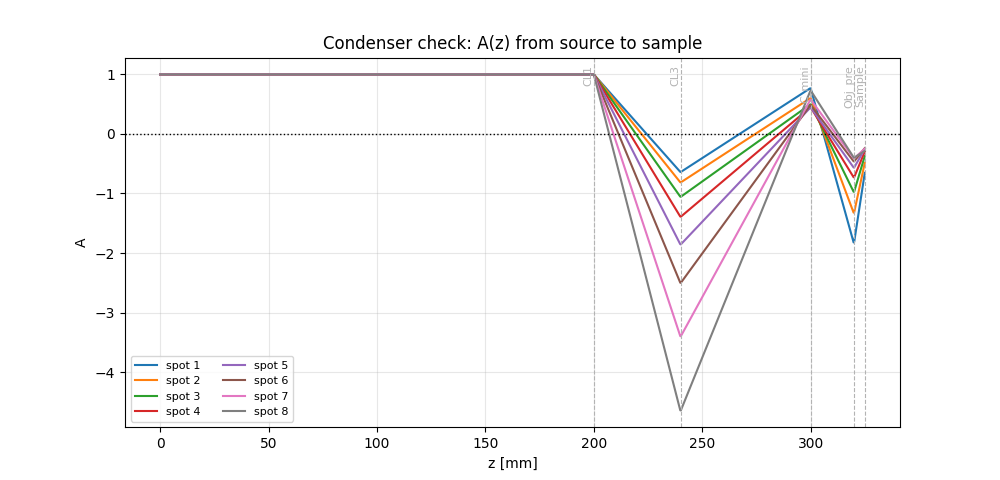

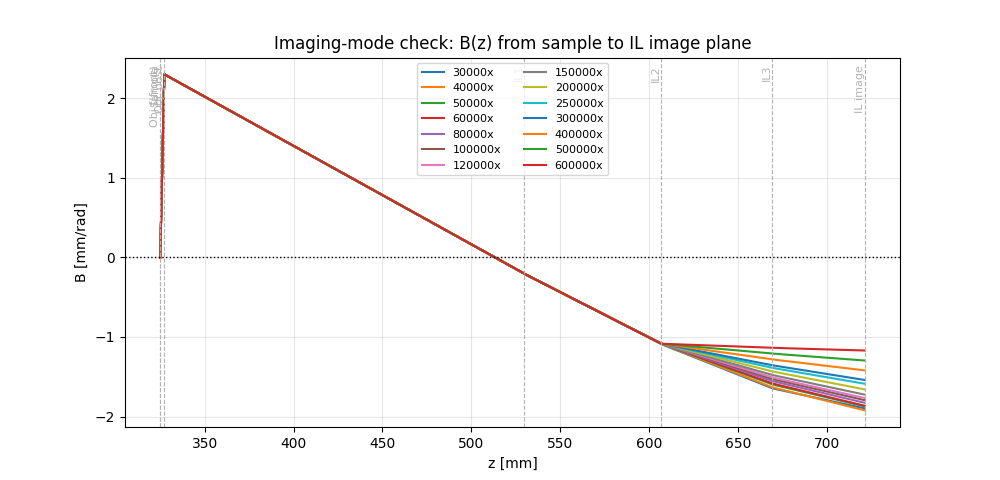

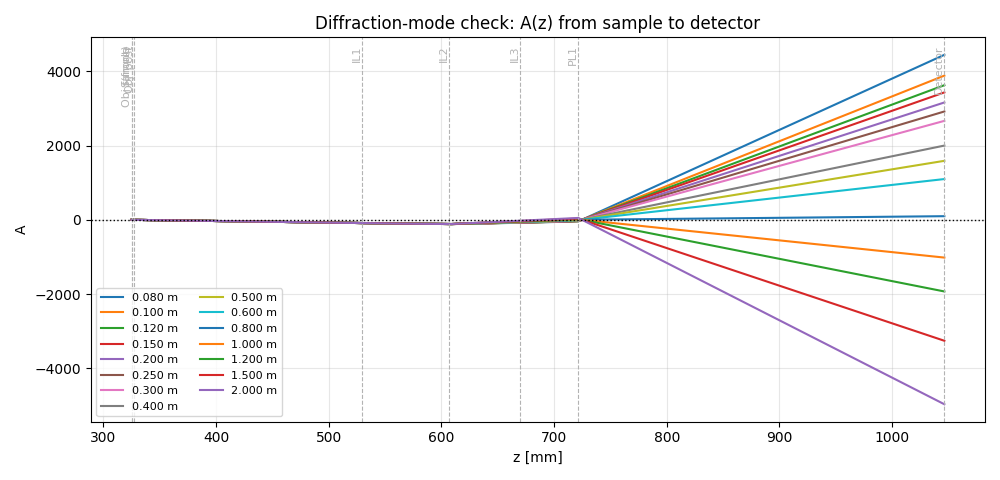

In [138]:
# Requested scalar ABCD checks plotted along the column.

z_source_abs = 0.0
z_sample_abs = z['Obj_prefield'] + geometry['d_ObjPrefield_to_Sample']
z_il_image_abs = z['IL3'] + geometry_mag['d_il3_to_image']
z_detector_abs = z['PL1'] + geometry['d_PL1_to_detector']
z_obj_front_focal_abs = z['Obj_post'] - f_obj_required_m


def _abcd_free_local(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def _abcd_lens_local(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def _abcd_trace_absolute(z_start, z_eval, lenses):
    """Return ABCD matrices evaluated after all lenses up to each absolute z in z_eval."""
    z_eval = np.asarray(z_eval, dtype=float)
    lenses = sorted([(float(z_l), float(f_l)) for z_l, f_l in lenses], key=lambda item: item[0])
    out = np.empty((z_eval.size, 2, 2), dtype=float)
    M = np.eye(2)
    z_prev = float(z_start)
    lens_idx = 0

    for i, z_now in enumerate(z_eval):
        while lens_idx < len(lenses) and lenses[lens_idx][0] <= z_now + 1e-12:
            z_lens, f_lens = lenses[lens_idx]
            if z_lens > z_prev + 1e-12:
                M = _abcd_free_local(z_lens - z_prev) @ M
                z_prev = z_lens
            M = _abcd_lens_local(f_lens) @ M
            lens_idx += 1
        if z_now > z_prev + 1e-12:
            out[i] = _abcd_free_local(z_now - z_prev) @ M
        else:
            out[i] = M
    return out


def _plot_component_lines(ax, z_positions_m, labels, color='0.7'):
    for z_pos, label in zip(z_positions_m, labels):
        ax.axvline(1e3 * float(z_pos), color=color, linestyle='--', linewidth=0.8)
        ax.text(1e3 * float(z_pos), 0.98, label, rotation=90, va='top', ha='right',
                transform=ax.get_xaxis_transform(), fontsize=8, color=color)


# --- 1) Condenser check: A(z) from source to sample ---
z_eval_cond = np.linspace(z_source_abs, z_sample_abs, 1200)
fig_cond, ax_cond = plt.subplots(figsize=(10, 4.8))
for row in results_cond:
    lenses_cond = [
        (z['CL1'], row['f_CL1']),
        (z['CL3'], row['f_CL3']),
        (z['C_mini'], optics['f_Cmini_m']),
        (z['Obj_prefield'], optics['f_ObjPrefield_m']),
    ]
    mats = _abcd_trace_absolute(z_source_abs, z_eval_cond, lenses_cond)
    A_vals = mats[:, 0, 0]
    ax_cond.plot(1e3 * z_eval_cond, A_vals, label=f"spot {int(row['spot_index'])}")

_plot_component_lines(
    ax_cond,
    [z['CL1'], z['CL3'], z['C_mini'], z['Obj_prefield'], z_sample_abs],
    ['CL1', 'CL3', 'C_mini', 'Obj_pre', 'Sample'],
)
ax_cond.axhline(0.0, color='k', linestyle=':', linewidth=1.0)
ax_cond.set_title('Condenser check: A(z) from source to sample')
ax_cond.set_xlabel('z [mm]')
ax_cond.set_ylabel('A')
ax_cond.legend(loc='best', ncols=2, fontsize=8)
ax_cond.grid(True, alpha=0.3)

print('=== Condenser A(sample) check ===')
for row in results_cond:
    lenses_cond = [
        (z['CL1'], row['f_CL1']),
        (z['CL3'], row['f_CL3']),
        (z['C_mini'], optics['f_Cmini_m']),
        (z['Obj_prefield'], optics['f_ObjPrefield_m']),
    ]
    A_sample = _abcd_trace_absolute(z_source_abs, [z_sample_abs], lenses_cond)[0, 0, 0]
    print(f"spot {int(row['spot_index'])}: A(sample) = {A_sample:.6e}")


# --- 2) Imaging check: B(z) from sample to IL image plane ---
# This includes explicit drift from sample to objective lens plane and marks
# the objective front focal plane for clarity.
z_eval_img = np.linspace(z_sample_abs, z_il_image_abs, 1500)
fig_img, ax_img = plt.subplots(figsize=(10, 4.8))
for control, row in zip(target_system_mags, mag_results):
    lenses_img = [
        (z['Obj_post'], f_obj_required_m),
        (z['IL1'], row['f1_m']),
        (z['IL2'], row['f2_m']),
        (z['IL3'], row['f3_m']),
    ]
    mats = _abcd_trace_absolute(z_sample_abs, z_eval_img, lenses_img)
    B_vals = mats[:, 0, 1]
    ax_img.plot(1e3 * z_eval_img, 1e3 * B_vals, label=f"{int(control)}x")

_plot_component_lines(
    ax_img,
    [z_sample_abs, z_obj_front_focal_abs, z['Obj_post'], z['IL1'], z['IL2'], z['IL3'], z_il_image_abs],
    ['Sample', 'Obj f(front)', 'Obj_post', 'IL1', 'IL2', 'IL3', 'IL image'],
)
ax_img.axhline(0.0, color='k', linestyle=':', linewidth=1.0)
ax_img.set_title('Imaging-mode check: B(z) from sample to IL image plane')
ax_img.set_xlabel('z [mm]')
ax_img.set_ylabel('B [mm/rad]')
ax_img.legend(loc='best', ncols=2, fontsize=8)
ax_img.grid(True, alpha=0.3)

print('\n=== Imaging B(IL image) check ===')
print(f"sample -> objective front focal plane: {(z_obj_front_focal_abs - z_sample_abs)*1e3:.6f} mm")
print(f"sample -> objective lens plane: {(z['Obj_post'] - z_sample_abs)*1e3:.6f} mm")
for control, row in zip(target_system_mags, mag_results):
    lenses_img = [
        (z['Obj_post'], f_obj_required_m),
        (z['IL1'], row['f1_m']),
        (z['IL2'], row['f2_m']),
        (z['IL3'], row['f3_m']),
    ]
    B_il_image = _abcd_trace_absolute(z_sample_abs, [z_il_image_abs], lenses_img)[0, 0, 1]
    print(f"mag {int(control):>6d}x: B(IL image) = {1e3 * B_il_image:.6f} mm/rad")


# --- 3) Diffraction check: A(z) from sample to detector ---
z_eval_diff = np.linspace(z_sample_abs, z_detector_abs, 1500)
fig_diff_abcd, ax_diff_abcd = plt.subplots(figsize=(10, 4.8))
for control, row in zip(target_camera_lengths_m, diff_results):
    lenses_diff = [
        (z['Obj_post'], f_obj_required_m),
        (z['IL1'], row['f1_m']),
        (z['IL2'], row['f2_m']),
        (z['IL3'], row['f3_m']),
        (z['PL1'], f_pl1_target_m),
    ]
    mats = _abcd_trace_absolute(z_sample_abs, z_eval_diff, lenses_diff)
    A_vals = mats[:, 0, 0]
    ax_diff_abcd.plot(1e3 * z_eval_diff, A_vals, label=f"{control:.3f} m")

_plot_component_lines(
    ax_diff_abcd,
    [z_sample_abs, z_obj_front_focal_abs, z['Obj_post'], z['IL1'], z['IL2'], z['IL3'], z['PL1'], z_detector_abs],
    ['Sample', 'Obj f(front)', 'Obj_post', 'IL1', 'IL2', 'IL3', 'PL1', 'Detector'],
)
ax_diff_abcd.axhline(0.0, color='k', linestyle=':', linewidth=1.0)
ax_diff_abcd.set_title('Diffraction-mode check: A(z) from sample to detector')
ax_diff_abcd.set_xlabel('z [mm]')
ax_diff_abcd.set_ylabel('A')
ax_diff_abcd.legend(loc='best', ncols=2, fontsize=8)
ax_diff_abcd.grid(True, alpha=0.3)

print('\n=== Diffraction A(detector) check ===')
for control, row in zip(target_camera_lengths_m, diff_results):
    lenses_diff = [
        (z['Obj_post'], f_obj_required_m),
        (z['IL1'], row['f1_m']),
        (z['IL2'], row['f2_m']),
        (z['IL3'], row['f3_m']),
        (z['PL1'], f_pl1_target_m),
    ]
    A_det = _abcd_trace_absolute(z_sample_abs, [z_detector_abs], lenses_diff)[0, 0, 0]
    print(f"camera length {control:>7.3f} m: A(detector) = {A_det:.6e}")

plt.tight_layout()

In [139]:
# Option-1 consistency check: fitted IL manifold with explicit objective decomposition.
#
# This writes the objective as: sample -> front focal offset -> focal drift -> lens,
# to make the sample-to-objective-focal distance explicit in the math.

if use_fitted_mode_tables:
    d_img_fit = np.array([d1i_f, d2_f, 1.0, d4_f], dtype=float)

    def _drift(d):
        return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)

    def _lens_phi(phi):
        return np.array([[1.0, 0.0], [-float(phi), 1.0]], dtype=float)

    def _il_matrix(phi, d):
        d1, d2, d3, d4 = d
        return _drift(d4) @ _lens_phi(phi[2]) @ _drift(d3) @ _lens_phi(phi[1]) @ _drift(d2) @ _lens_phi(phi[0]) @ _drift(d1)

    # Explicit objective decomposition from sample plane:
    # 1) drift from sample to front focal plane: (u - f)
    # 2) drift f to lens plane
    # 3) objective lens action
    d_sample_to_obj_focal = u_obj_m - f_obj_required_m
    phi_obj = 1.0 / f_obj_required_m
    M_obj = _lens_phi(phi_obj) @ _drift(f_obj_required_m) @ _drift(d_sample_to_obj_focal)
    B_obj = M_obj[0, 1]

    B_il_vals = []
    B_total_vals = []
    corrected_vals = []

    for j in range(x_img_fit.shape[1]):
        phi = alpha_f * (x_img_fit[:, j] ** 2)
        M_il = _il_matrix(phi, d_img_fit)
        M_total = M_il @ M_obj

        A_il, B_il = M_il[0, 0], M_il[0, 1]
        B_total = M_total[0, 1]

        corrected = B_total - A_il * B_obj

        B_il_vals.append(B_il)
        B_total_vals.append(B_total)
        corrected_vals.append(corrected)

    B_il_vals = np.asarray(B_il_vals, dtype=float)
    B_total_vals = np.asarray(B_total_vals, dtype=float)
    corrected_vals = np.asarray(corrected_vals, dtype=float)

    print('=== Option-1 consistency (fitted manifold + objective block) ===')
    print(f"sample -> objective front focal plane: {1e3*d_sample_to_obj_focal:.6f} mm")
    print(f"objective focal distance f_obj:        {1e3*f_obj_required_m:.6f} mm")
    print(f"sample -> objective lens plane u_obj: {1e3*u_obj_m:.6f} mm")
    print(f"max |B_il| at IL constrained plane:   {1e3*np.max(np.abs(B_il_vals)):.6e} mm/rad")
    print(f"max |B_total(sample->IL image)|:      {1e3*np.max(np.abs(B_total_vals)):.6e} mm/rad")
    print(f"max |B_total - A_il*B_obj|:           {1e3*np.max(np.abs(corrected_vals)):.6e} mm/rad")
else:
    print('Fitted mode tables are not active; option-1 consistency check skipped.')

=== Option-1 consistency (fitted manifold + objective block) ===
sample -> objective front focal plane: 0.028109 mm
objective focal distance f_obj:        2.271891 mm
sample -> objective lens plane u_obj: 2.300000 mm
max |B_il| at IL constrained plane:   7.105427e-12 mm/rad
max |B_total(sample->IL image)|:      1.539165e+02 mm/rad
max |B_total - A_il*B_obj|:           8.326673e-14 mm/rad


In [140]:
# Bottom-line B=0 validation including sample + objective + IL block.
# This complements the IL-only checks by explicitly composing objective and IL matrices.

if len(mag_results) == 0:
    print('No imaging-mode rows found; run the mode-table cells first.')
else:
    b_il_vals = []
    b_full_vals = []
    b_relation_residual = []

    # Objective block from sample plane to objective image plane.
    M_obj_block = build_chain([
        ('P', u_obj_m),
        ('L', f_obj_required_m),
        ('P', v_obj_m),
    ])
    _, B_obj, _, D_obj = extract_abcd(M_obj_block)

    for row in mag_results:
        M_il = build_chain([
            ('P', geometry_mag['d_obj_image_to_il1']),
            ('L', row['f1_m']),
            ('P', geometry_mag['d_il1_to_il2']),
            ('L', row['f2_m']),
            ('P', geometry_mag['d_il2_to_il3']),
            ('L', row['f3_m']),
            ('P', geometry_mag['d_il3_to_image']),
        ])

        # Full chain from sample to IL image plane: objective followed by IL block.
        M_full = M_il @ M_obj_block

        A_il, B_il, _, _ = extract_abcd(M_il)
        _, B_full, _, _ = extract_abcd(M_full)

        # Correct composition identity for B of M_full = M_il @ M_obj.
        B_expected = A_il * B_obj + B_il * D_obj

        b_il_vals.append(float(B_il))
        b_full_vals.append(float(B_full))
        b_relation_residual.append(float(B_full - B_expected))

    b_il_vals = np.asarray(b_il_vals, dtype=float)
    b_full_vals = np.asarray(b_full_vals, dtype=float)
    b_relation_residual = np.asarray(b_relation_residual, dtype=float)

    print('=== Bottom check: sample + objective + IL -> IL image plane ===')
    print(f'Objective block B_obj = {1e3 * B_obj:+.6f} mm/rad')
    print(f'Objective block D_obj = {D_obj:+.6f}')
    print('Control    B_il [mm/rad]    B_full [mm/rad]')
    for control, b_il, b_full in zip(target_system_mags, b_il_vals, b_full_vals):
        print(f"{int(control):>7d}  {1e3*b_il:>14.6f}  {1e3*b_full:>15.6f}")

    print(f"max |B_il|                     = {1e3*np.max(np.abs(b_il_vals)):.6e} mm/rad")
    print(f"max |B_full|                   = {1e3*np.max(np.abs(b_full_vals)):.6e} mm/rad")
    print(f"max |B_full-(A_il*B_obj+B_il*D_obj)| = {1e3*np.max(np.abs(b_relation_residual)):.6e} mm/rad")

    if np.max(np.abs(b_il_vals)) < 1e-9:
        print('IL-only B is numerically near zero at the constrained plane.')
    else:
        print('IL-only B is not near zero; check fitted manifold usage and geometry consistency.')

=== Bottom check: sample + objective + IL -> IL image plane ===
Objective block B_obj = -0.000000 mm/rad
Objective block D_obj = -0.012373
Control    B_il [mm/rad]    B_full [mm/rad]
  30000      153.431672        -1.898359
  40000      155.415477        -1.922904
  50000      151.339992        -1.872479
  60000      150.737689        -1.865027
  80000      147.754946        -1.828122
 100000      145.024454        -1.794339
 120000      142.873509        -1.767726
 150000      139.405805        -1.724821
 200000      134.119933        -1.659421
 250000      128.354413        -1.588086
 300000      124.528248        -1.540746
 400000      114.786681        -1.420217
 500000      104.760246        -1.296163
 600000       94.591925        -1.170354
max |B_il|                     = 1.554155e+02 mm/rad
max |B_full|                   = 1.922904e+00 mm/rad
max |B_full-(A_il*B_obj+B_il*D_obj)| = 2.168404e-16 mm/rad
IL-only B is not near zero; check fitted manifold usage and geometry consisten